In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('QVI_data.csv')
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [66]:
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(1)

In [68]:
duplicate = df[df.duplicated(keep=False)]
duplicate

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
106247,107024,2018-10-01,107,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0,175,SMITHS,OLDER SINGLES/COUPLES,Premium
106249,107024,2018-10-01,107,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0,175,SMITHS,OLDER SINGLES/COUPLES,Premium


In [69]:
#drop duplicate
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [70]:
#change date Dtype
df['DATE'] = pd.to_datetime(df['DATE'])

In [71]:
df.dtypes

LYLTY_CARD_NBR               int64
DATE                datetime64[ns]
STORE_NBR                    int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                   object
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                       object
LIFESTAGE                   object
PREMIUM_CUSTOMER            object
dtype: object

In [72]:
df['MONTH'] = df['DATE'].dt.to_period('M')
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11


In [73]:
#price per unit
df['PRICE'] = df['TOT_SALES'] / df['PROD_QTY']
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,PRICE
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10,3.0
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09,2.7
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03,3.6
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03,3.0
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11,1.9


In [74]:
#get monthly sales information
store_measures = df.groupby(['STORE_NBR', 'MONTH']).agg(
    TOTAL_SALES =('TOT_SALES', 'sum'),
    NCUSTOMERS =('LYLTY_CARD_NBR', 'nunique'),
    NTRX =('TXN_ID', 'nunique'),
    NCHIPS =('PROD_QTY', 'sum'),
    AVG_UNITPRICE = ('PRICE', 'mean')
).reset_index()
store_measures

,STORE_NBR,MONTH,TOTAL_SALES,NCUSTOMERS,NTRX,NCHIPS,AVG_UNITPRICE
0,1,2018-07,206.9,49,52,62,3.384615
1,1,2018-08,176.1,42,43,54,3.329070
2,1,2018-09,278.8,59,62,75,3.685484
3,1,2018-10,188.1,44,45,58,3.288889
4,1,2018-11,192.6,46,47,57,3.412766
...,...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,91,4.358333
3165,272,2019-03,442.3,50,53,101,4.350943
3166,272,2019-04,445.1,54,55,105,4.248214
3167,272,2019-05,314.6,34,40,71,4.437500


In [75]:
store_measures['NTRX_PerC'] = store_measures["NTRX"] / store_measures["NCUSTOMERS"]
store_measures['NCHIPS_PerC'] = store_measures["NCHIPS"] /store_measures["NCUSTOMERS"]
store_measures.drop(columns=["NTRX", "NCHIPS"], inplace=True)
store_measures

,STORE_NBR,MONTH,TOTAL_SALES,NCUSTOMERS,AVG_UNITPRICE,NTRX_PerC,NCHIPS_PerC
0,1,2018-07,206.9,49,3.384615,1.061224,1.265306
1,1,2018-08,176.1,42,3.329070,1.023810,1.285714
2,1,2018-09,278.8,59,3.685484,1.050847,1.271186
3,1,2018-10,188.1,44,3.288889,1.022727,1.318182
4,1,2018-11,192.6,46,3.412766,1.021739,1.239130
...,...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,4.358333,1.066667,2.022222
3165,272,2019-03,442.3,50,4.350943,1.060000,2.020000
3166,272,2019-04,445.1,54,4.248214,1.018519,1.944444
3167,272,2019-05,314.6,34,4.437500,1.176471,2.088235


In [76]:
#only 6 months' worth of data exists before the control period (2019/02)
store_measures['MONTH'].min(), store_measures['MONTH'].max()

(Period('2018-07', 'M'), Period('2019-06', 'M'))

In [77]:
#filter stores that have full 6 months before the control period (2019-02)
filtered = store_measures[store_measures['MONTH'] < pd.Period('2019-02', 'M')]
#count months per store
month_counts = filtered.groupby('STORE_NBR')['MONTH'].nunique()
n_months = filtered['MONTH'].nunique()
#stores that belong in observation  period
full_obs =  month_counts[month_counts == n_months].index
full_obs

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       263, 264, 265, 266, 267, 268, 269, 270, 271, 272],
      dtype='int64', name='STORE_NBR', length=260)

In [78]:
#pretrial measures for filtered stores
pre_trial = filtered[(filtered['STORE_NBR'].isin(full_obs))]
pre_trial

,STORE_NBR,MONTH,TOTAL_SALES,NCUSTOMERS,AVG_UNITPRICE,NTRX_PerC,NCHIPS_PerC
0,1,2018-07,206.9,49,3.384615,1.061224,1.265306
1,1,2018-08,176.1,42,3.329070,1.023810,1.285714
2,1,2018-09,278.8,59,3.685484,1.050847,1.271186
3,1,2018-10,188.1,44,3.288889,1.022727,1.318182
4,1,2018-11,192.6,46,3.412766,1.021739,1.239130
...,...,...,...,...,...,...,...
3159,272,2018-09,304.7,32,4.283333,1.125000,2.218750
3160,272,2018-10,430.6,44,4.345098,1.136364,2.250000
3161,272,2018-11,376.2,41,4.308889,1.097561,2.121951
3162,272,2018-12,403.9,47,4.512766,1.000000,1.893617


In [79]:
pre_trial['STORE_NBR'].nunique()

260

In [80]:
trial_stores = [77, 86, 88]

In [81]:
#calculate correlation between trial and the rest of the stores
def get_correlations(metricCol, trialStore, inputTable=pre_trial):
    """calculate correlation measures looping through control store.
    Args:
    metricCol: Name of column containing the store's metric to perform correlation test on.
    trialStore: number of trial stores.
    inputTable: Monthly correlation table between trial and each control store.
    Returns:
    DataFrame: Monthly correlation table between trial and control stores.
    """
    control_stores = inputTable[~inputTable["STORE_NBR"].isin(trial_stores)]["STORE_NBR"].unique()
    corrs = pd.DataFrame(columns = ["MONTH", "Trial_Store", "Control_Store", "Corr_Score"])
    trial_store = inputTable[inputTable["STORE_NBR"] == trialStore][metricCol].reset_index()
    for control in control_stores:
        concat_df = pd.DataFrame(columns = ["MONTH", "Trial_Store", "Control_Store", "Corr_Score"])
        control_store = inputTable[inputTable["STORE_NBR"] == control][metricCol].reset_index()
        concat_df["Corr_Score"] = trial_store.corrwith(control_store, axis=1)
        concat_df["Trial_Store"] = trialStore
        concat_df["Control_Store"] = control
        concat_df["MONTH"] = list(inputTable[inputTable["STORE_NBR"] == trialStore]["MONTH"])
        corrs = pd.concat([corrs, concat_df])
    return corrs

In [82]:
#correlation among stores
corr_table = pd.DataFrame()
for trial_st in trial_stores:
    corr_table = pd.concat([corr_table, get_correlations(["TOTAL_SALES", "NCUSTOMERS", "AVG_UNITPRICE", "NTRX_PerC", "NCHIPS_PerC"], trial_st)])
corr_table.head(8)

C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

,MONTH,Trial_Store,Control_Store,Corr_Score
0,2018-07,77,1,0.070349
1,2018-08,77,1,0.027173
2,2018-09,77,1,0.002416
3,2018-10,77,1,-0.020095
4,2018-11,77,1,0.029947
5,2018-12,77,1,0.063942
6,2019-01,77,1,0.001475
0,2018-07,77,2,0.143021


In [83]:
def calculateMagnitudeDistance(metricCol, storeComparison, inputTable=pre_trial):
    control_store_nbrs = inputTable[~inputTable["STORE_NBR"].isin([77, 86, 88])]["STORE_NBR"].unique()
    dists = pd.DataFrame()
    trial_store = inputTable[inputTable["STORE_NBR"] == storeComparison][metricCol]
    for control in control_store_nbrs:
        concat_df  = abs(inputTable[inputTable["STORE_NBR"] == storeComparison].reset_index()[metricCol] - inputTable[inputTable["STORE_NBR"] == control].reset_index()[metricCol])
        concat_df["MONTH"] = list(inputTable[inputTable["STORE_NBR"] == storeComparison]["MONTH"])
        concat_df["Trial_Store"] = storeComparison
        concat_df["Control_Store"] = control
        dists = pd.concat([dists, concat_df])
    for col in metricCol:
        dists[col] = 1 - ((dists[col] - dists[col].min()) / (dists[col].max() - dists[col].min()))
    dists["magnitude"] = dists[metricCol].mean(axis=1)
    return dists

In [84]:
dist_table = pd.DataFrame()
for trial_num in [77, 86, 88]:
    dist_table = pd.concat([dist_table, calculateMagnitudeDistance(["TOTAL_SALES", "NTRX_PerC", "NCHIPS_PerC", "AVG_UNITPRICE"], trial_num)])
    
dist_table.head(8)
dist_table

,TOTAL_SALES,NTRX_PerC,NCHIPS_PerC,AVG_UNITPRICE,MONTH,Trial_Store,Control_Store,magnitude
0,0.935431,0.956123,0.739412,0.905890,2018-07,77,1,0.884214
1,0.942972,0.993541,0.802894,0.935723,2018-08,77,1,0.918782
2,0.961503,0.991768,0.730041,0.733649,2018-09,77,1,0.854240
3,0.988221,0.989036,0.940460,0.653008,2018-10,77,1,0.892681
4,0.962149,0.868852,0.730358,0.791892,2018-11,77,1,0.838313
...,...,...,...,...,...,...,...,...
2,0.207554,0.469697,0.779879,0.916273,2018-09,88,272,0.593351
3,0.346797,0.534816,0.796875,0.971437,2018-10,88,272,0.662481
4,0.286706,0.615078,0.813241,0.958502,2018-11,88,272,0.668382
5,0.347151,0.343915,0.699748,0.971247,2018-12,88,272,0.590515


In [85]:
#select control stores based on monthly sales and number of customers
def combine_corr_dist(metricCol, storeComparison, inputTable=pre_trial):
    corrs = get_correlations(metricCol, storeComparison, inputTable)
    dists = calculateMagnitudeDistance(metricCol, storeComparison, inputTable)
    dists = dists.drop(metricCol, axis=1)
    combine = pd.merge(corrs, dists, on=["MONTH", "Trial_Store", "Control_Store"])
    return combine

In [88]:
compare_metrics_table1 = pd.DataFrame()
for trial_num in [77, 86, 88]:
    compare_metrics_table1 = pd.concat([compare_metrics_table1, combine_corr_dist(["TOTAL_SALES"], trial_num)])

C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

In [87]:
corr_weight = 0.5
dist_weight = 1 - corr_weight

In [89]:
grouped_comparison_table1 = compare_metrics_table1.groupby(["Trial_Store", "Control_Store"]).mean().reset_index()
grouped_comparison_table1["CompScore"] = (corr_weight * grouped_comparison_table1["Corr_Score"]) + (dist_weight * grouped_comparison_table1["magnitude"])
for trial_num in compare_metrics_table1["Trial_Store"].unique():
    print(grouped_comparison_table1[grouped_comparison_table1["Trial_Store"] == trial_num].sort_values(ascending=False, by="CompScore").head(), '\n')

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
218           77            233  2018-10         1.0   0.986477   0.993238
239           77            255  2018-10         1.0   0.979479   0.989739
177           77            188  2018-10         1.0   0.977663   0.988831
49            77             53  2018-10         1.0   0.976678   0.988339
120           77            131  2018-10         1.0   0.976267   0.988134 

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
356           86            109  2018-10         1.0   0.966783   0.983391
401           86            155  2018-10         1.0   0.965876   0.982938
464           86            222  2018-10         1.0   0.962280   0.981140
467           86            225  2018-10         1.0   0.960512   0.980256
471           86            229  2018-10         1.0   0.951704   0.975852 

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
551           88     

In [ ]:
#Based on total sales
#trail stores for 77: 233, 255, 188
#trial stores for 86: 109, 155, 222
#trial stores for 88: 40, 26, 72

In [92]:
#odentify top 5 highest compatible trail stores based on number of customers
compare_metrics_table2 = pd.DataFrame()
for trial_num in [77, 86, 88]:
    compare_metrics_table2 = pd.concat([compare_metrics_table2, combine_corr_dist(["NCUSTOMERS"], trial_num)])

C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([corrs, concat_df])
C:\Users\piyum\AppData\Local\Temp\ipykernel_19600\103174450.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

In [95]:
grouped_comparison_table2 = compare_metrics_table2.groupby(["Trial_Store", "Control_Store"]).mean().reset_index()
grouped_comparison_table2["CompScore"] = (corr_weight * grouped_comparison_table2["Corr_Score"]) + (dist_weight * grouped_comparison_table2["magnitude"])
for trial_num in compare_metrics_table2["Trial_Store"].unique():
    print(grouped_comparison_table2[grouped_comparison_table2["Trial_Store"] == trial_num].sort_values(ascending=False, by="CompScore").head(), '\n')

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
218           77            233  2018-10         1.0   0.993132   0.996566
38            77             41  2018-10         1.0   0.976648   0.988324
101           77            111  2018-10         1.0   0.968407   0.984203
105           77            115  2018-10         1.0   0.967033   0.983516
15            77             17  2018-10         1.0   0.965659   0.982830 

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
401           86            155  2018-10         1.0   0.986772   0.993386
467           86            225  2018-10         1.0   0.969577   0.984788
356           86            109  2018-10         1.0   0.969577   0.984788
471           86            229  2018-10         1.0   0.964286   0.982143
293           86             39  2018-10         1.0   0.961640   0.980820 

     Trial_Store  Control_Store    MONTH  Corr_Score  magnitude  CompScore
736           88     

In [ ]:
#Based on No of customer sales
#trail stores for 77: 233, 41, 111
#trial stores for 86: 155, 225, 109
#trial stores for 88: 237, 203, 40

In [96]:
for trial_num in compare_metrics_table2["Trial_Store"].unique():
    a = grouped_comparison_table1[grouped_comparison_table1["Trial_Store"] == trial_num].sort_values(ascending=False, by="CompScore").set_index(["Trial_Store", "Control_Store"])["CompScore"]
    b = grouped_comparison_table2[grouped_comparison_table2["Trial_Store"] == trial_num].sort_values(ascending=False, by="CompScore").set_index(["Trial_Store", "Control_Store"])["CompScore"]
    print((pd.concat([a,b], axis=1).sum(axis=1)/2).sort_values(ascending=False).head(3), '\n')

Trial_Store  Control_Store
77           233              0.994902
             41               0.986020
             46               0.984762
dtype: float64 

Trial_Store  Control_Store
86           155              0.988162
             109              0.984090
             225              0.982522
dtype: float64 

Trial_Store  Control_Store
88           40               0.970895
             26               0.958929
             72               0.954079
dtype: float64 



In [ ]:
#Based on the highest avg
#trail stores for 77: 233
#trial stores for 86: 155
#trial stores for 88: 40

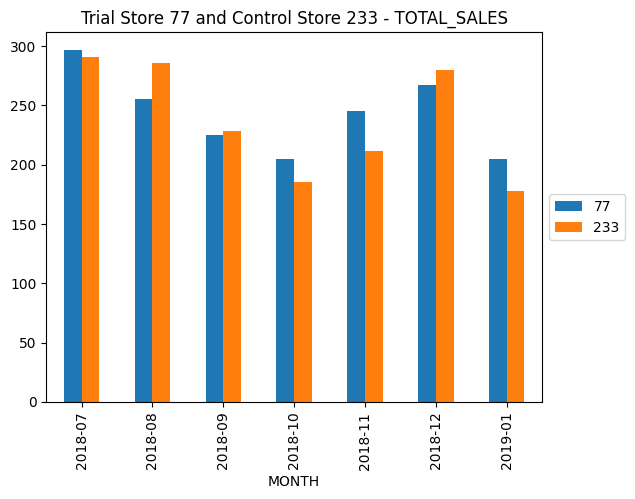

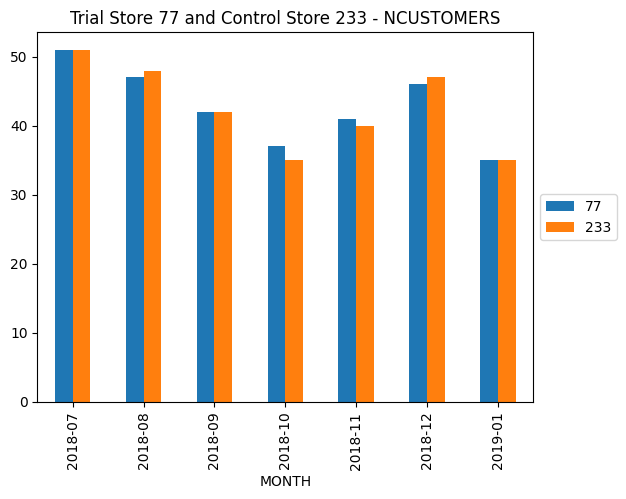

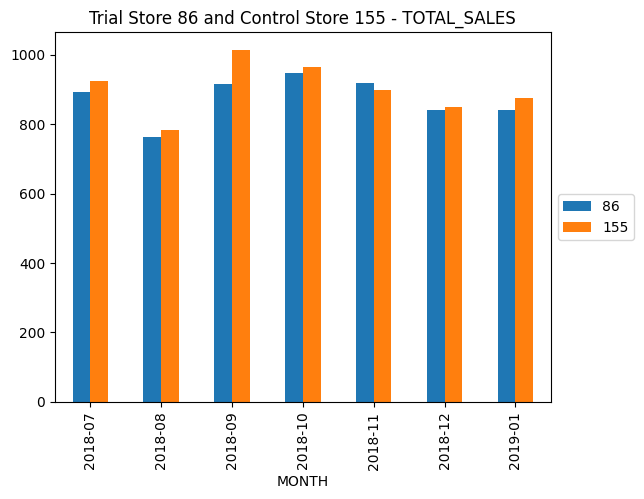

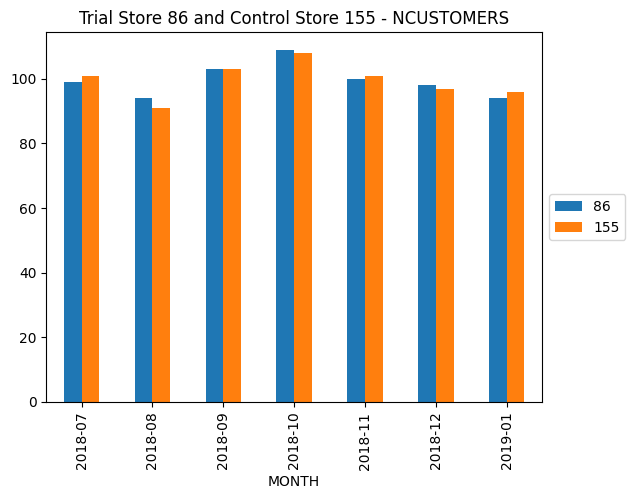

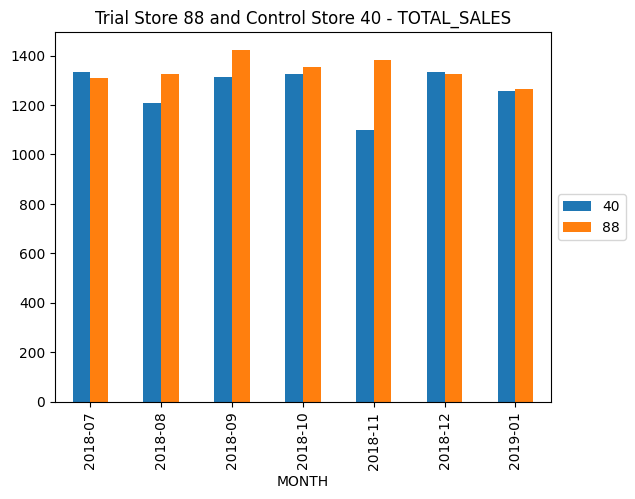

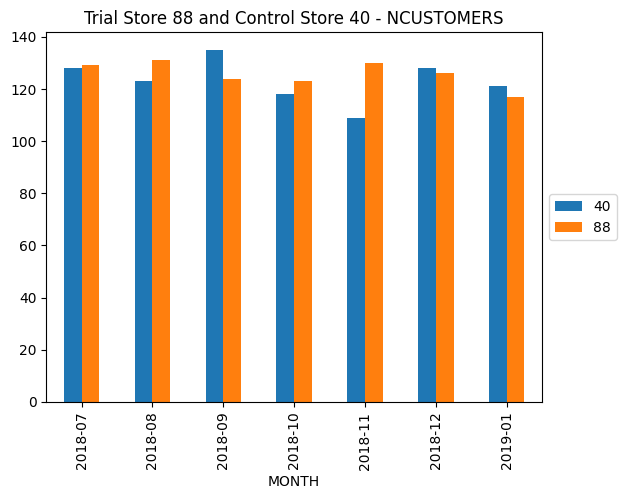

In [101]:
trial_control_dict = {77:233, 86:155, 88:40}
for key, val in trial_control_dict.items():
    pre_trial[pre_trial["STORE_NBR"].isin([key, val])].groupby(
        ["MONTH", "STORE_NBR"]).sum()["TOTAL_SALES"].unstack().plot.bar()
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(key)+" and Control Store "+str(val)+" - TOTAL_SALES")
    plt.show()
    pre_trial[pre_trial["STORE_NBR"].isin([key, val])].groupby(
    ["MONTH", "STORE_NBR"]).sum()["NCUSTOMERS"].unstack().plot.bar()
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title("Trial Store "+str(key)+" and Control Store "+str(val)+" - NCUSTOMERS")
    plt.show()
    print('\n')

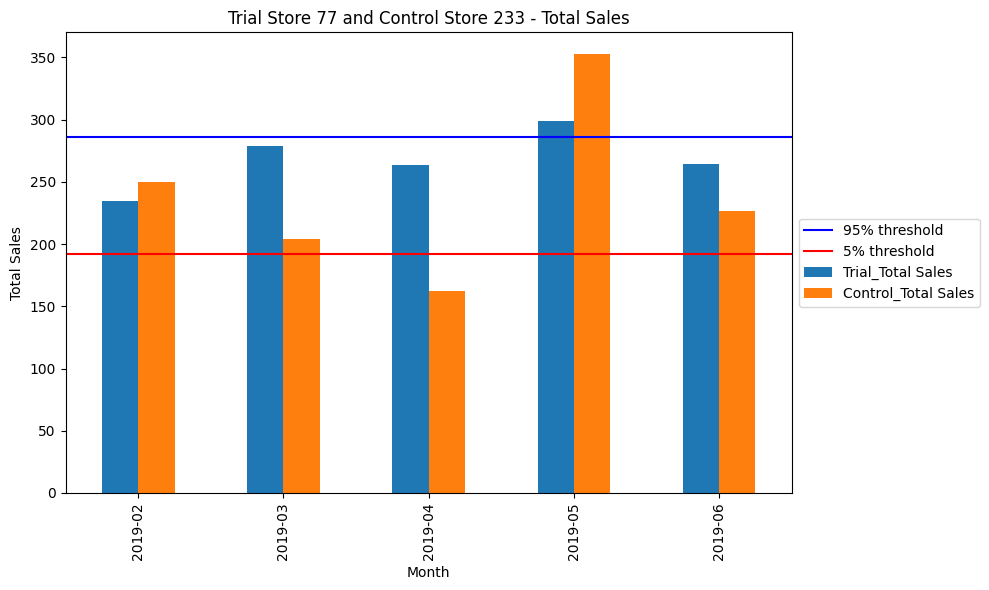

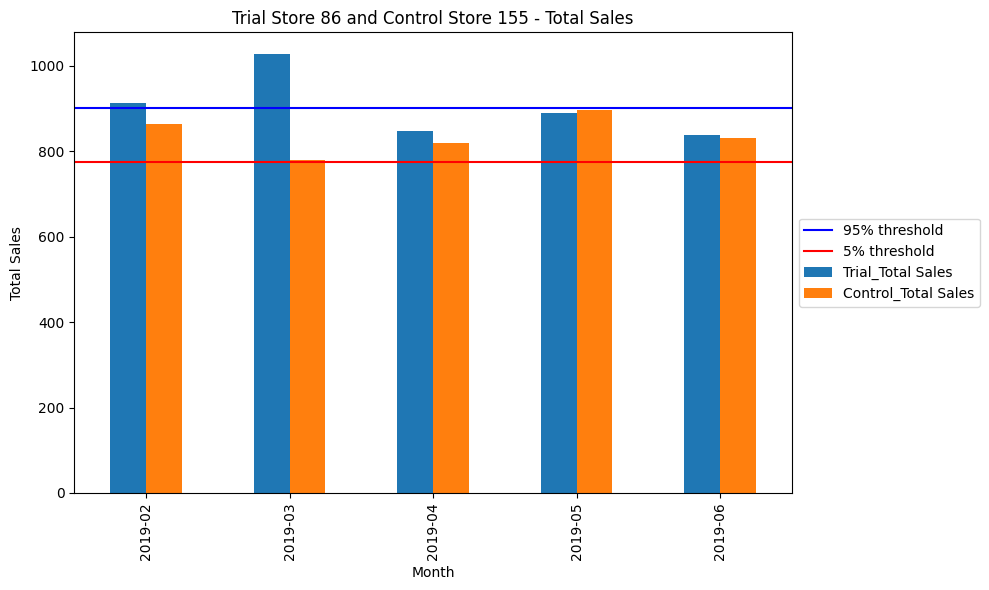

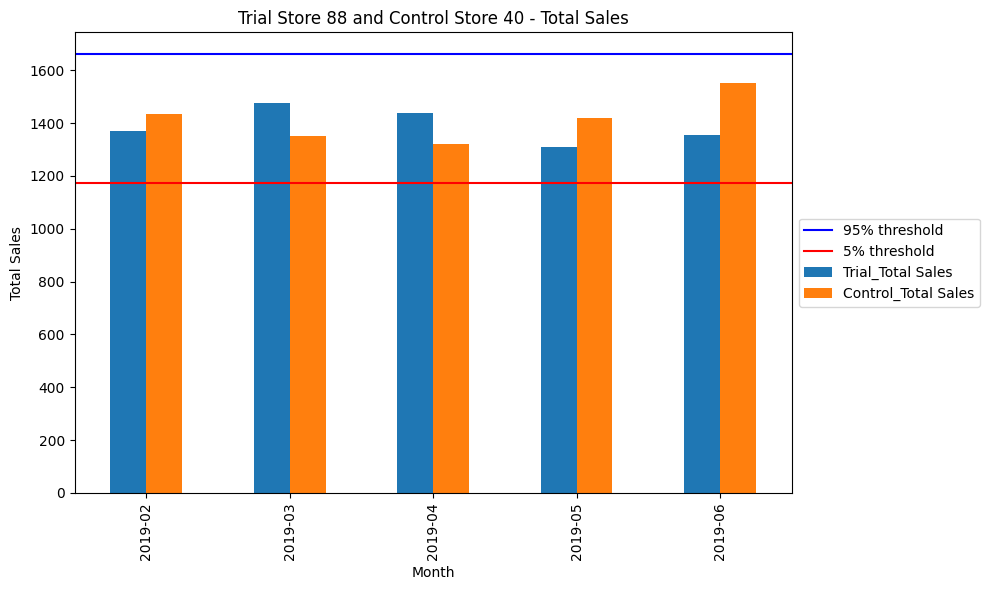

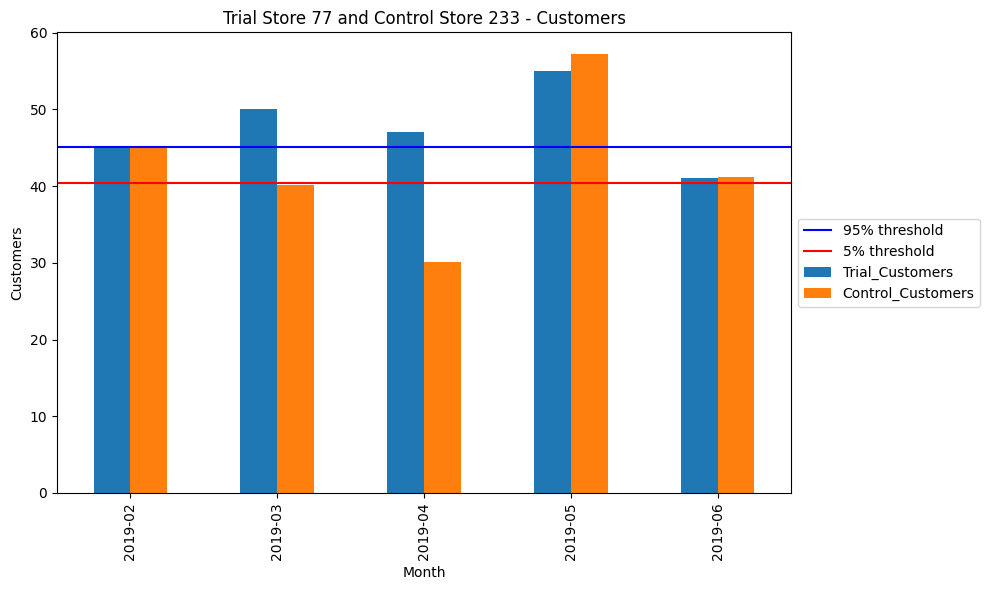

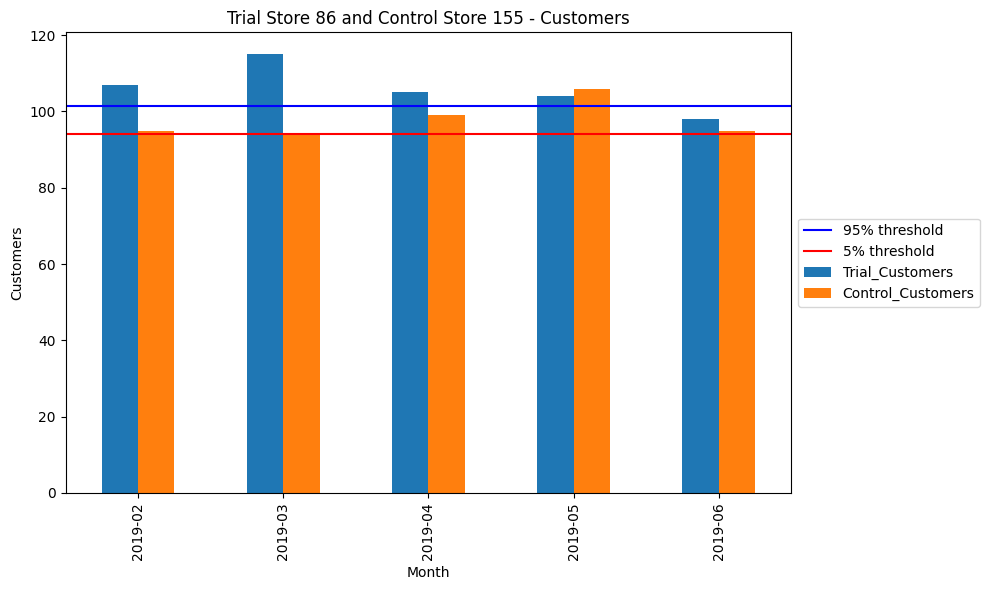

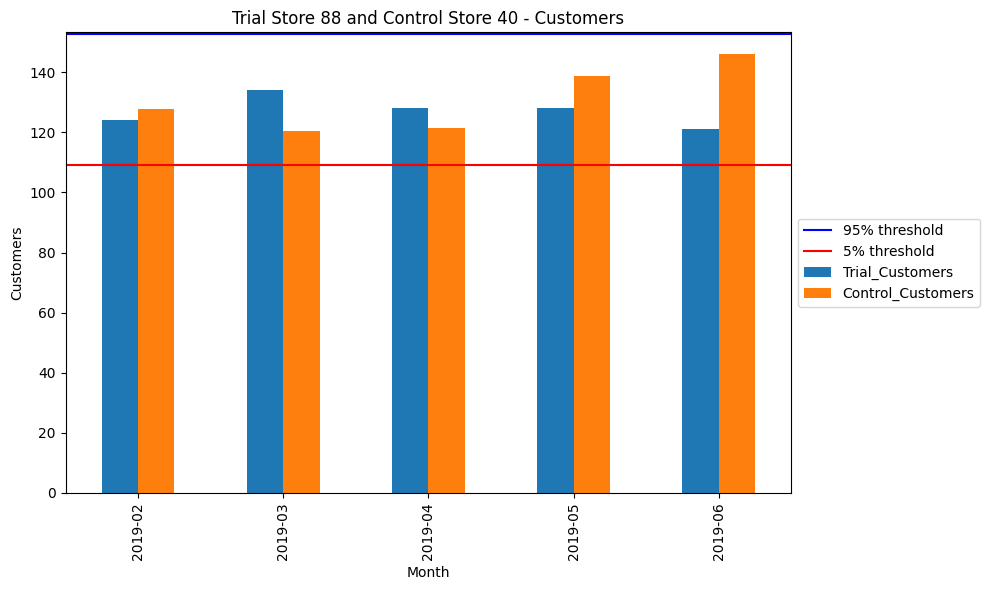

In [105]:
from scipy.stats import ttest_ind, t

# --- SCALING RATIOS ---
# Calculate how much to scale each control store to match its trial store

def get_scaling_ratio(trial_store, control_store, data):
    pre = data[data['MONTH'] < pd.Period('2019-02', 'M')]
    trial_sum = pre[pre['STORE_NBR'] == trial_store]['TOTAL_SALES'].sum()
    control_sum = pre[pre['STORE_NBR'] == control_store]['TOTAL_SALES'].sum()
    return trial_sum / control_sum

def get_ncust_scaling_ratio(trial_store, control_store, data):
    pre = data[data['MONTH'] < pd.Period('2019-02', 'M')]
    trial_sum = pre[pre['STORE_NBR'] == trial_store]['NCUSTOMERS'].sum()
    control_sum = pre[pre['STORE_NBR'] == control_store]['NCUSTOMERS'].sum()
    return trial_sum / control_sum

trial_control_dict = {77: 233, 86: 155, 88: 40}

sales_ratios = {trial: get_scaling_ratio(trial, control, store_measures) 
                for trial, control in trial_control_dict.items()}
ncust_ratios = {trial: get_ncust_scaling_ratio(trial, control, store_measures) 
                for trial, control in trial_control_dict.items()}

# --- SCALE CONTROL STORES ACROSS ALL MONTHS ---

def scale_control(data, metric, ratios, trial_control_dict):
    control_stores = list(trial_control_dict.values())
    scaled = data[data['STORE_NBR'].isin(control_stores)][['STORE_NBR', 'MONTH', metric]].copy()
    # map control store to its trial store ratio
    control_to_trial = {v: k for k, v in trial_control_dict.items()}
    scaled['Scaled'] = scaled.apply(
        lambda row: row[metric] * ratios[control_to_trial[row['STORE_NBR']]], axis=1
    )
    return scaled

scaled_sales = scale_control(store_measures, 'TOTAL_SALES', sales_ratios, trial_control_dict)
scaled_ncust = scale_control(store_measures, 'NCUSTOMERS', ncust_ratios, trial_control_dict)

# Split into pre-trial and trial periods
trial_scaled_sales = scaled_sales[scaled_sales['MONTH'] >= pd.Period('2019-02', 'M')]
pretrial_scaled_sales = scaled_sales[scaled_sales['MONTH'] < pd.Period('2019-02', 'M')]

trial_scaled_ncust = scaled_ncust[scaled_ncust['MONTH'] >= pd.Period('2019-02', 'M')]
pretrial_scaled_ncust = scaled_ncust[scaled_ncust['MONTH'] < pd.Period('2019-02', 'M')]

trial_period = store_measures[(store_measures['MONTH'] >= pd.Period('2019-02', 'M')) & 
                               (store_measures['MONTH'] <= pd.Period('2019-04', 'M'))]

# --- PERCENTAGE DIFFERENCE TABLE ---

def build_pct_diff(scaled_all, trial_data, metric, scaled_col, trial_control_dict):
    rows = []
    for month in scaled_all['MONTH'].unique():
        for trial, control in trial_control_dict.items():
            ctrl_val = scaled_all[(scaled_all['STORE_NBR'] == control) & 
                                   (scaled_all['MONTH'] == month)]['Scaled']
            trial_val = trial_data[(trial_data['STORE_NBR'] == trial) & 
                                    (trial_data['MONTH'] == month)][metric]
            if len(ctrl_val) > 0 and len(trial_val) > 0:
                c = float(ctrl_val.values[0])
                tr = float(trial_val.values[0])
                pct_diff = (tr - c) / ((tr + c) / 2)
                period = 'pre' if month < pd.Period('2019-02', 'M') else 'trial'
                rows.append({'MONTH': month, 'Trial': trial, 'Control': control, 
                             'pct_diff': pct_diff, 'period': period})
    return pd.DataFrame(rows)

pct_diff_sales = build_pct_diff(scaled_sales, store_measures, 'TOTAL_SALES', 'Scaled', trial_control_dict)
pct_diff_ncust = build_pct_diff(scaled_ncust, store_measures, 'NCUSTOMERS', 'Scaled', trial_control_dict)

# --- PLOT WITH THRESHOLDS ---

def plot_with_thresholds(trial_control_dict, trial_scaled, store_measures, 
                          pct_diff_df, metric, trial_metric_col, scaled_col='Scaled',
                          label='Total Sales'):
    for trial, control in trial_control_dict.items():
        # Get trial period data
        a = trial_scaled[trial_scaled['STORE_NBR'] == control][['MONTH', 'Scaled']].rename(
            columns={'Scaled': f'Control_{label}'})
        b = store_measures[(store_measures['STORE_NBR'] == trial) & 
                           (store_measures['MONTH'] >= pd.Period('2019-02', 'M'))][['MONTH', metric]].rename(
            columns={metric: f'Trial_{label}'})
        
        comb = b.merge(a, on='MONTH').set_index('MONTH')
        comb.index = comb.index.astype(str)
        
        # Calculate thresholds from pre-trial std dev
        pre = pct_diff_df[(pct_diff_df['Trial'] == trial) & (pct_diff_df['period'] == 'pre')]
        std = pre['pct_diff'].std()
        ctrl_mean = trial_scaled[trial_scaled['STORE_NBR'] == control]['Scaled'].mean()
        thresh95 = ctrl_mean + (ctrl_mean * std * 2)
        thresh5 = ctrl_mean - (ctrl_mean * std * 2)

        # Plot
        ax = comb.plot.bar(figsize=(10, 6))
        plt.axhline(y=thresh95, linewidth=1.5, color='b', label='95% threshold')
        plt.axhline(y=thresh5, linewidth=1.5, color='r', label='5% threshold')
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
        plt.title(f'Trial Store {trial} and Control Store {control} - {label}')
        plt.xlabel('Month')
        plt.ylabel(label)
        plt.tight_layout()
        plt.savefig(f'TS_{trial}_CS_{control}_{label.replace(" ","_")}.png', bbox_inches='tight')
        plt.show()
        print('\n')

# Run for sales
plot_with_thresholds(trial_control_dict, trial_scaled_sales, store_measures,
                     pct_diff_sales, 'TOTAL_SALES', 'TOTAL_SALES', label='Total Sales')

# Run for customers
plot_with_thresholds(trial_control_dict, trial_scaled_ncust, store_measures,
                     pct_diff_ncust, 'NCUSTOMERS', 'NCUSTOMERS', label='Customers')

In [ ]:
#The Trial store 77 sales for Feb, March, and April exceeds 95% threshold of control store. Same goes to store 86 sales for all 3 trial months.

#Trial store 77: Control store 233
#Trial store 86: Control store 155
#Trial store 88: Control store 40
#Both trial store 77 and 86 showed significant increase in Total Sales and Number of Customers during trial period. But not for trial store 88. Perhaps the client knows if there's anything about trial 88 that differs it from the other two trial.
#Overall the trial showed positive significant result.